# Hough Transform

## 2D median filter

In [109]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


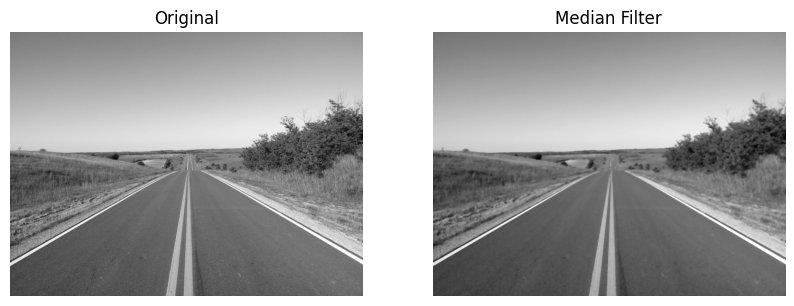

In [110]:
laneimg = cv2.imread("lane.jpg", 0)   

filteredLaneImage = cv2.medianBlur(laneimg, 5)  # To remove high frequency noise whilst preserving edges for edge detection later on

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(laneimg, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(filteredLaneImage, cmap='gray')
plt.title("Median Filter")
plt.axis("off")

plt.show()


## Canny Edge Detection

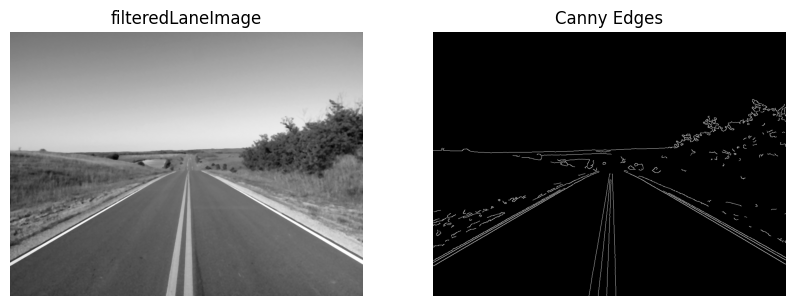

In [111]:
edges = cv2.Canny(filteredLaneImage, 100, 200)
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(filteredLaneImage, cmap='gray')
plt.title("filteredLaneImage")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(edges, cmap='gray')
plt.title("Canny Edges")
plt.axis("off")

plt.show()


## ROI

(np.float64(-0.5), np.float64(1023.5), np.float64(767.5), np.float64(-0.5))

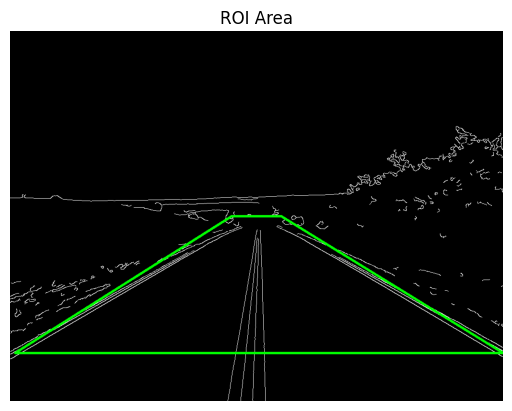

In [112]:
img_color = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)

height, width = edges.shape

polygon = np.array([
    (int(width*0.01), int(height*0.87)),
    (int(width*0.45), int(height*0.5)),
    (int(width*0.55), int(height*0.5)),
    (int(width), int(height*0.87))
])

cv2.polylines(img_color, [polygon], True, (0,255,0), 3)

plt.imshow(img_color)
plt.title("ROI Area")
plt.axis("off")

In [ ]:
def region_of_interest(img):
    height = img.shape[0]
    width = img.shape[1]

    polygon = np.array([[
        (int(width*0.01), int(height*0.85)),
        (int(width*0.45), int(height*0.5)),
        (int(width*0.55), int(height*0.5)),
        (int(width), int(height*0.85))
    ]], dtype=np.int32)
      
    # Create mask
    # mask = np.zeros_like(img)
    mask = np.zeros((height, width), dtype=np.uint8)     # Changed to force the mask to be 1-channel (grayscale), regardless of 'img'

    # Fill polygon
    cv2.fillPoly(mask, polygon, 255)

    # Apply mask
    # masked_image = cv2.bitwise_and(img, mask)
    masked_image = cv2.bitwise_and(img, img, mask=mask)
    

    return masked_image


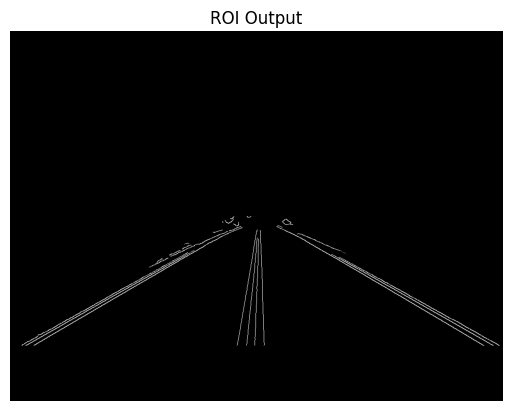

In [114]:
roi_edges = region_of_interest(edges)
plt.imshow(roi_edges, cmap='gray')
plt.title("ROI Output")
plt.axis("off")
plt.show()


### What is the problem we're trying to solve? 

**Our Edge detection algorithm worked!** and it successfully detected the pixels that define those edges. 
However, there is **no mathematical correlation between all those collective pixels** to tell my system that they are all a part of the same line.

Each point in the image space has infinite lines going throug it, however, infinity does NOT mean everything, it just means too many to count.
So, only one of those infinite lines of the first and second pixels are the exact same. 
Or, if I have multiple points, only one minimzes the perpendicular distance to each pixel.

But, how do I find this line?

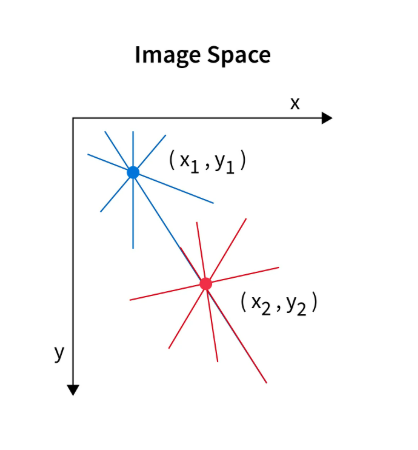 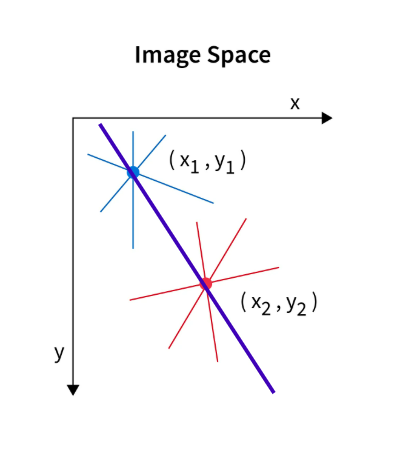


This is where the Hough Transform comes in. 

It asks: "Okay, every straight line in my image has a normal vector (a perpendicular line connecting it to the origin). That normal vector has a length ($\rho$) and an angle ($\theta$). I can express the distance from the origin to that *entire line* as $\rho = x \cos(\theta) + y \sin(\theta)$. 

Since Pixel 1 at $(x_1, y_1)$ could belong to infinite possible lines, I can substitute $\theta$ from 0 to 180 to map out all the possible $(\rho, \theta)$ combinations for it. Then I ask: which of these specific $(\rho, \theta)$ pairs will land in the exact same "bucket" (or grid cell that represents a pair of [ρ and θ]) as the pairs I get when I map out all possible lines for Pixel 2 at $(x_2, y_2)$? 

After drawing all the possible values (in the parameter space) for those lines' parameters for each point that was given to me by my edge detection algorithm, I see which ($\rho$) and ($\theta$) were used the most or which "grid cell" in the parameter space had the most curves pass through it. 

And then I will use these parameters to draw a line which is supposed to replace my old discrete line of pixels with my newly made continuous line.
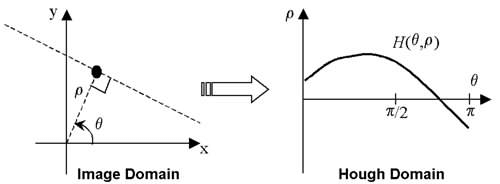

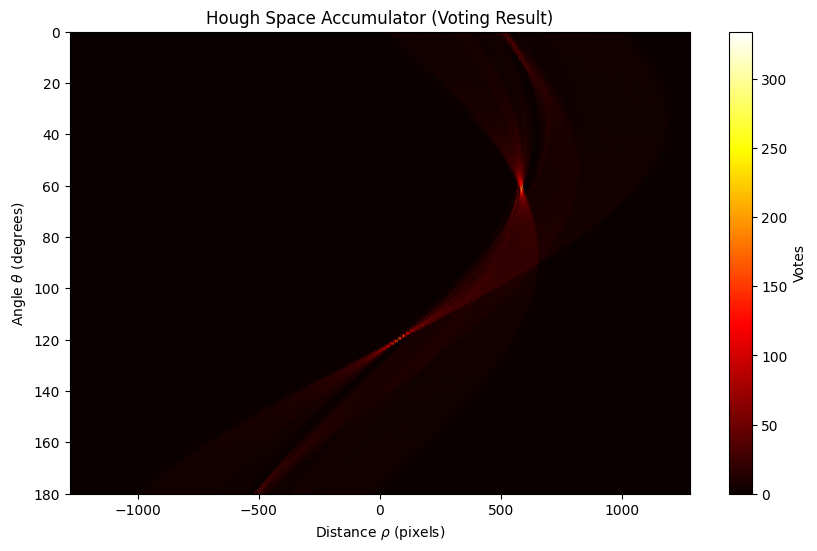

In [115]:
# 2.3.1 Accumulation into (rho, theta)-space

import numpy as np
import matplotlib.pyplot as plt


# Theta ranges from 0 to 180 degrees (converted to radians for math functions)
thetas = np.deg2rad(np.arange(0, 180))

height, width = roi_edges.shape  # find the maximum possible distance (ρ) which is the image diagonal

diag_len = int(np.ceil(np.sqrt(width**2 + height**2)))

# Rho can be negative depending on the angle, so we range from -diag_len to +diag_len
rhos = np.arange(-diag_len, diag_len + 1)

# 2. Initialize the Accumulator H(theta, rho) with zeros
# Rows = thetas (180), Columns = rhos (2 * diag_len + 1) (the +1 is the zero [for e.g. diag = 100, so possible values are -100->0, 0, 0->100])
accumulator = np.zeros((len(thetas), len(rhos)), dtype=np.uint64) 

# 3. Find the (x, y) coordinates of all edge points (where pixel value > 0)
y_idxs, x_idxs = np.nonzero(roi_edges)

# 4. Voting process (Vectorized for Jupyter performance)
# For each edge point (x, y) in the image
for i in range(len(x_idxs)):
    x = x_idxs[i]
    y = y_idxs[i]
    
    # Calculate rho for all theta values simultaneously: rho = x*cos(θ) + y*sin(θ)
    rho_vals = x * np.cos(thetas) + y * np.sin(thetas)
    
    # Round to nearest integer and shift by diag_len to fit into our array indices (0 to max_index) 
    rho_idxs = np.round(rho_vals).astype(int) + diag_len
    
    # H(theta, rho) = H(theta, rho) + 1
    for theta_idx in range(len(thetas)):
        accumulator[theta_idx, rho_idxs[theta_idx]] += 1

# 5. Plot the accumulator array as an image
plt.figure(figsize=(10, 6))
# Using 'hot' colormap is standard for Hough space to show "bright" peaks
plt.imshow(accumulator, cmap='hot', aspect='auto', 
           extent=[-diag_len, diag_len, 180, 0])
plt.title('Hough Space Accumulator (Voting Result)')    
plt.xlabel(r'Distance $\rho$ (pixels)')
plt.ylabel(r'Angle $\theta$ (degrees)')
plt.colorbar(label='Votes')
plt.show()

Detected 4 distinct lines after NMS and thresholding.


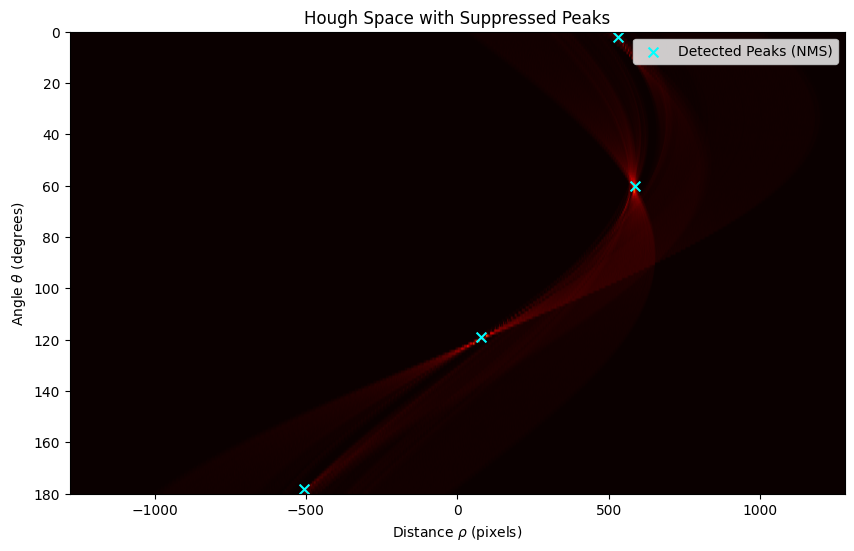

In [119]:
# 2.3.2 Refining Coordinates and HT Post-Processing (NMS)

from scipy.ndimage import maximum_filter

# Define parameters for thresholding and non-maximum suppression
# Minimum pixels/votes a line must have to be considered valid
VOTE_THRESHOLD = 60 

# The size of the local neighborhood to check for a maximum (controls suppression)
NEIGHBORHOOD_SIZE = 50 # (Basically chooses the "grid cell" with the highest votes among its 50 neighbouring cells, any other similar/neighbouring lines are disqualified)

# 1. Non-Maximum Suppression (NMS)
# maximum_filter replaces every pixel with the maximum value in its neighborhood
# By comparing the accumulator to the filtered version, we isolate the local peaks
local_max = maximum_filter(accumulator, size=NEIGHBORHOOD_SIZE) == accumulator

# 2. Thresholding
# We also want to ignore "peaks" that are just background noise
background = (accumulator > VOTE_THRESHOLD)

# 3. Combine both masks: it must be a local maximum AND above the vote threshold
valid_peaks = local_max & background

# Extract the indices of these peaks
peak_theta_idxs, peak_rho_idxs = np.where(valid_peaks)        # i.e. indices where valid_peaks is "True" or has a value

# Map indices back to actual theta (degrees) and rho values
peak_thetas = np.rad2deg(thetas[peak_theta_idxs])
peak_rhos = rhos[peak_rho_idxs]

print(f"Detected {len(peak_thetas)} distinct lines after NMS and thresholding.")

# 4. Plot the peaks on top of the Hough Space to verify
plt.figure(figsize=(10, 6))
plt.imshow(accumulator, cmap='hot', aspect='auto', 
           extent=[-diag_len, diag_len, 180, 0])
plt.scatter(peak_rhos, peak_theta_idxs, color='cyan', marker='x', s=50, label='Detected Peaks (NMS)')
plt.title('Hough Space with Suppressed Peaks')
plt.xlabel(r'Distance $\rho$ (pixels)')
plt.ylabel(r'Angle $\theta$ (degrees)')
plt.legend()
plt.show()

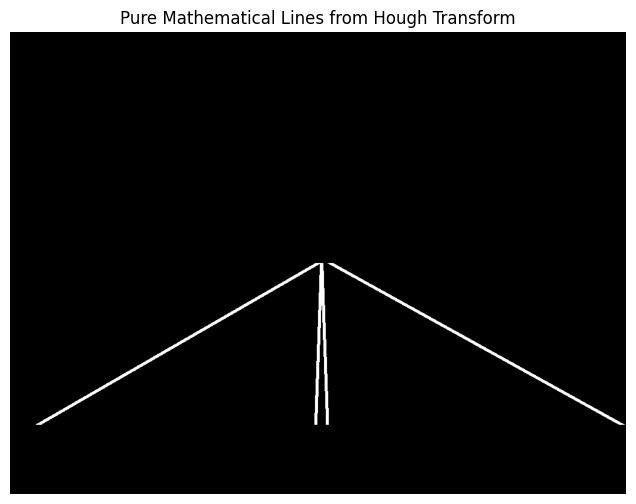

In [ ]:
# =========================================================
# Extra Code visualization and understanding
# =========================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Instead of copying the image, we create a completely black canvas 
# with the exact same dimensions as 'laneimg'
smooth_lines_img = np.zeros_like(laneimg)

# We need a massive multiplier to stretch the line across the entire screen
L = 2000 

# We loop through the peaks we extracted from the 'accumulator' in step 2.3.2
for rho, theta_deg in zip(peak_rhos, peak_thetas):
    
    # Convert theta back to radians for numpy math
    theta = np.deg2rad(theta_deg)
    
    # Calculate the directional components
    a = np.cos(theta)
    b = np.sin(theta)
    
    # 1. Find the anchor point (x0, y0)
    x0 = a * rho
    y0 = b * rho
    
    # 2. Calculate point 1 (stretch way out in one direction)
    x1 = int(x0 + L * (-b))
    y1 = int(y0 + L * (a))
    
    # 3. Calculate point 2 (stretch way out in the opposite direction)
    x2 = int(x0 - L * (-b))
    y2 = int(y0 - L * (a))
    
    # 4. Draw the smooth, continuous white line on the black background
    # (255, 255, 255) is pure white. Thickness is set to 3.
    cv2.line(smooth_lines_img, (x1, y1), (x2, y2), (255, 255, 255), 3)
    cropped_lines_img = region_of_interest(smooth_lines_img)
# Plot the final result
plt.figure(figsize=(10, 6))
# Using cmap='gray' keeps the classic black-and-white look of the earlier edge mask
plt.imshow(cropped_lines_img, cmap='gray') 
plt.title("Pure Mathematical Lines from Hough Transform")
plt.axis('off')
plt.show()

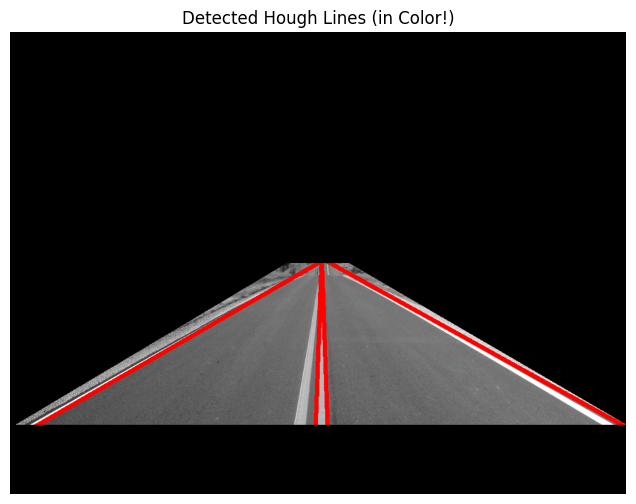

In [ ]:
# =========================================================
# Drawing Colored Lines on the Image
# =========================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt


color_canvas = cv2.cvtColor(laneimg, cv2.COLOR_BGR2RGB)

# 2. Make a copy so we don't overwrite our original variable
line_image = np.copy(color_canvas)

# We need a massive multiplier to stretch the line
L = 2000 

# Loop through every winning (rho, theta) pair we found
for rho, theta_deg in zip(peak_rhos, peak_thetas):
    
    # Convert theta back to radians
    theta = np.deg2rad(theta_deg)
    
    a = np.cos(theta)
    b = np.sin(theta)
    
    x0 = a * rho              # Here we get one point on the line (intersection between the polar form line and its normal)
    y0 = b * rho              # We will then stretch it out to two points one in each direction of the normal to the polar form line.
    
    x1 = int(x0 + L * (-b))  # It might appear that we're using sines for the x coordinates but that's just becuase
    y1 = int(y0 + L * (a))   # We want to extend the normal line, not the polar form line itself. 
    x2 = int(x0 - L * (-b))
    y2 = int(y0 - L * (a))
    
    # 3. Draw the line on our RGB canvas
    # Since we already converted to RGB, (255, 0, 0) will correctly draw pure RED.
    cv2.line(line_image, (x1, y1), (x2, y2), (255, 0, 0), 5) 

# 4. Apply your Region of Interest mask to chop the lines
# (Make sure your region_of_interest function can handle 3-channel images!)
cropped_lines_img = region_of_interest(line_image)

# Plot the final result
plt.figure(figsize=(10, 6))
plt.imshow(cropped_lines_img) 
plt.title("Detected Hough Lines (in Color!)")
plt.axis('off')
plt.show()